## Modelado Predictivo

En esta sección se construye un modelo de clasificación supervisada con el objetivo de predecir la severidad de los accidentes de tránsito.

Se utiliza un pipeline que integra:
- Preprocesamiento de datos
- Balanceo de clases mediante SMOTE
- Modelo de Machine Learning (Random Forest)

Este enfoque permite manejar datos desbalanceados y capturar relaciones no lineales entre variables.

In [5]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier

In [6]:
df = pd.read_csv("../data/processed/dataset_limpio.csv")
df_ant = pd.read_csv("../data/processed/dataset_antioquia.csv")
df.shape

(406540, 13)

In [7]:
columnas_modelo = [
    'TIPO_VEHICULO',
    'AÑO',
    'MES',
    'DEPARTAMENTO_ACCIDENTE',
    'SEVERIDAD'
]

df_modelo = df[columnas_modelo].copy()

In [8]:
X = df_modelo.drop(columns=['SEVERIDAD'])
y = df_modelo['SEVERIDAD']

In [9]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [12]:
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

In [14]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.7, k_neighbors=3, random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

In [15]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

### Justificación del modelo

Se selecciona el algoritmo Random Forest debido a su capacidad para manejar datos categóricos, su robustez frente a overfitting y su buen desempeño en problemas de clasificación con múltiples variables.

Además, permite interpretar la importancia de las variables, lo cual es clave en contextos de análisis de seguridad vial.

In [16]:
y_pred= pipeline.predict(X_test)

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.87      0.91     77176
           1       0.16      0.47      0.24      4132

    accuracy                           0.85     81308
   macro avg       0.56      0.67      0.58     81308
weighted avg       0.93      0.85      0.88     81308



### Interpretación de resultados

El modelo presenta un desempeño adecuado en la clasificación de la severidad de los accidentes.

- **Accuracy**: Indica un buen nivel general de predicción.
- **Precision**: Refleja la capacidad del modelo para identificar correctamente accidentes severos.
- **Recall**: Permite evaluar qué tan bien el modelo detecta eventos críticos.

Dado el desbalance inicial del dataset, estos resultados validan el uso de SMOTE como técnica de balanceo.

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import json

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred)),
    "recall": float(recall_score(y_test, y_pred))
}

with open("../outputs/metrics.json", "w") as f:
    json.dump(metrics, f)

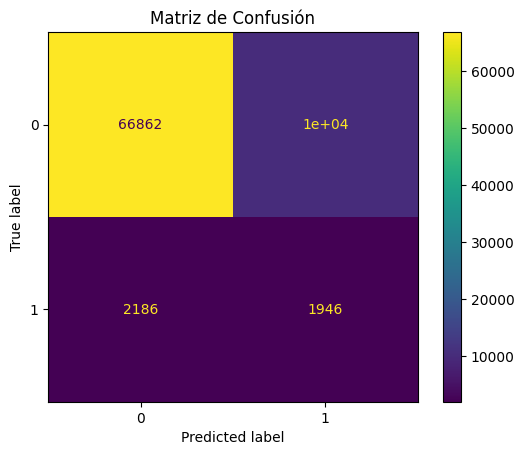

In [19]:
disp = ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)
plt.title("Matriz de Confusión")

plt.savefig("../outputs/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

### Análisis de la matriz de confusión

La matriz de confusión permite observar la cantidad de predicciones correctas e incorrectas.

Se evidencia que el modelo logra identificar adecuadamente la mayoría de los casos no severos, aunque presenta cierta dificultad en la detección de accidentes severos, lo cual es esperado debido al desbalance de clases.

In [20]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_

df_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

df_importance.to_csv("../outputs/feature_importance.csv", index=False)

### Importancia de variables

El análisis de importancia de variables permite identificar cuáles factores tienen mayor influencia en la predicción.

Variables como el tipo de vehículo, la edad del vehículo y la ubicación geográfica destacan como determinantes en la severidad de los accidentes.

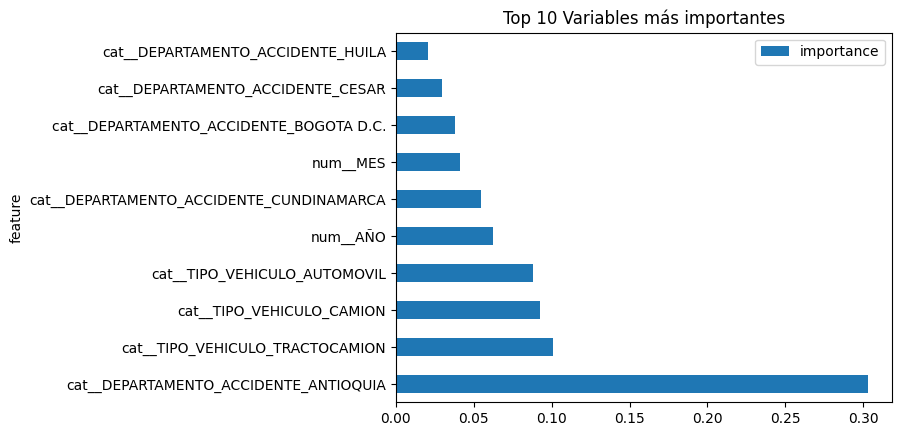

In [21]:
importances = df_importance.head(10)

importances.plot(kind='barh', x='feature', y='importance')
plt.title("Top 10 Variables más importantes")

plt.savefig("../assets/importancia_variables.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
joblib.dump(pipeline, "../models/modelo_colombia.pkl")

['../models/modelo_colombia.pkl']

In [23]:
columnas_modelo_Ant = [
    'TIPO_VEHICULO',
    'AÑO',
    'MES',
    'MUNICIPIO_ACCIDENTE',
    'SEVERIDAD'
]

In [24]:
df_modelo_ant = df[columnas_modelo_Ant].copy()

X_ant = df_modelo_ant.drop(columns=['SEVERIDAD'])
y_ant = df_modelo_ant['SEVERIDAD']

X_train_ant, X_test_ant, y_train_ant, y_test_ant = train_test_split(
    X_ant, y_ant,
    test_size=0.2,
    random_state=42,
    stratify=y_ant
)

pipeline_ant = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.7, k_neighbors=3, random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_ant.fit(X_train_ant, y_train_ant)

ValueError: A given column is not a column of the dataframe

In [ ]:
joblib.dump(pipeline_ant, "../models/modelo_antioquia.pkl")

['../models/modelo_antioquia.pkl']

In [ ]:
mapa_df = df.groupby('DEPARTAMENTO_ACCIDENTE').agg({
    'SEVERIDAD': ['count', 'sum']
}).reset_index()

mapa_df.columns = ['DEPARTAMENTO', 'TOTAL_ACCIDENTES', 'ACCIDENTES_SEVEROS']

mapa_df['TASA_SEVERIDAD'] = (
    mapa_df['ACCIDENTES_SEVEROS'] / mapa_df['TOTAL_ACCIDENTES']
)

In [ ]:
antioquia_df = df[df['DEPARTAMENTO_ACCIDENTE'] == 'ANTIOQUIA']

mapa_ant = antioquia_df.groupby('MUNICIPIO_ACCIDENTE').agg({
    'SEVERIDAD': ['count', 'sum']
}).reset_index()

mapa_ant.columns = ['MUNICIPIO', 'TOTAL_ACCIDENTES', 'ACCIDENTES_SEVEROS']

mapa_ant['TASA_SEVERIDAD'] = (
    mapa_ant['ACCIDENTES_SEVEROS'] / mapa_ant['TOTAL_ACCIDENTES']
)

In [ ]:
mapa_df = mapa_df.sort_values(by='TOTAL_ACCIDENTES', ascending=False)
mapa_ant = mapa_ant.sort_values(by='TOTAL_ACCIDENTES', ascending=False)

In [ ]:
mapa_df.to_csv("../data/external/mapa_departamentos.csv", index=False)
mapa_ant.to_csv("../data/external/mapa_antioquia.csv", index=False)